In [1]:
import torch
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.datasets.utils import dataset_to_policy_features
from lerobot.policies.act.configuration_act import ACTConfig
from lerobot.policies.act.modeling_act import ACTPolicy
from lerobot.configs.types import FeatureType
from lerobot.datasets.factory import resolve_delta_timestamps
import torchvision

c:\Users\wangzhian\.conda\envs\nvidia\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Policy Configuration and Initialize

In [10]:
data_root = "./data/cmirobot"
repo_id="cmirobot/s0100"
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")


# When starting from scratch (i.e. not from a pretrained policy), we need to specify 2 things before
# creating the policy:
#   - input/output shapes: to properly size the policy
#   - dataset stats: for normalization and denormalization of input/outputs
dataset_metadata = LeRobotDatasetMetadata(repo_id, root=data_root)
features = dataset_to_policy_features(dataset_metadata.features)
output_features = {key: ft for key, ft in features.items() if ft.type is FeatureType.ACTION}
input_features = {key: ft for key, ft in features.items() if key not in output_features}
input_features.pop("observation.camera1")
input_features.pop("observation.camera2")
# Policies are initialized with a configuration class, in this case `DiffusionConfig`. For this example,
# we'll just use the defaults and so no arguments other than input/output features need to be passed.
cfg = ACTConfig(input_features=input_features, output_features=output_features, chunk_size= 10, n_action_steps=10)
# This allows us to construct the data with action chunking
delta_timestamps = resolve_delta_timestamps(cfg, dataset_metadata)
# We can now instantiate our policy with this config and the dataset stats.
policy = ACTPolicy(cfg, dataset_stats=dataset_metadata.stats)
policy.train()
policy.to(device)

ACTPolicy(
  (normalize_inputs): Normalize(
    (buffer_observation_image1): ParameterDict(
        (mean): Parameter containing: [torch.FloatTensor of size 3x1x1]
        (std): Parameter containing: [torch.FloatTensor of size 3x1x1]
    )
    (buffer_observation_image2): ParameterDict(
        (mean): Parameter containing: [torch.FloatTensor of size 3x1x1]
        (std): Parameter containing: [torch.FloatTensor of size 3x1x1]
    )
    (buffer_observation_state): ParameterDict(
        (mean): Parameter containing: [torch.FloatTensor of size 27]
        (std): Parameter containing: [torch.FloatTensor of size 27]
    )
  )
  (normalize_targets): Normalize(
    (buffer_action): ParameterDict(
        (mean): Parameter containing: [torch.FloatTensor of size 7]
        (std): Parameter containing: [torch.FloatTensor of size 7]
    )
  )
  (unnormalize_outputs): Unnormalize(
    (buffer_action): ParameterDict(
        (mean): Parameter containing: [torch.FloatTensor of size 7]
        (st

## Load Dataset

In [11]:
from torchvision import transforms

class AddGaussianNoise(object):
    """
    Adds Gaussian noise to a tensor.
    """
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        # Adds noise: tensor remains a tensor.
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"

# Create a transformation pipeline that converts a PIL image to a tensor, then adds noise.
transform = transforms.Compose([
    AddGaussianNoise(mean=0., std=0.02),
    transforms.Lambda(lambda x: x.clamp(0, 1))
])

# We can then instantiate the dataset with these delta_timestamps configuration.
# dataset = LeRobotDataset(repo_id, delta_timestamps=delta_timestamps, root=data_root, image_transforms=transform)
dataset = LeRobotDataset(repo_id, delta_timestamps=delta_timestamps, root=data_root)

# Then we create our optimizer and dataloader for offline training.
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-4)
dataloader = torch.utils.data.DataLoader(
    dataset,
    num_workers=4,
    batch_size=5,
    shuffle=True
)
for batch in dataloader:
    print(f"{batch["observation.image2"].shape=}")  # (32, 4, c, h, w)
    print(f"{batch['observation.state'].shape=}")  # (32, 6, c)
    print(f"{batch['action'].shape=}")  # (32, 64, c)
    break

print(f"{policy.config.input_features=}")
print(f"{policy.config.output_features=}")
print(f"{delta_timestamps=}")

batch["observation.image2"].shape=torch.Size([5, 3, 800, 600])
batch['observation.state'].shape=torch.Size([5, 27])
batch['action'].shape=torch.Size([5, 10, 7])
policy.config.input_features={'observation.image1': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 800, 600)), 'observation.image2': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 800, 600)), 'observation.state': PolicyFeature(type=<FeatureType.STATE: 'STATE'>, shape=(27,))}
policy.config.output_features={'action': PolicyFeature(type=<FeatureType.ACTION: 'ACTION'>, shape=(7,))}
delta_timestamps={'action': [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]}


## Train

The trained checkpoint will be saved in './ckpt/act_y' folder.

In [7]:
# Number of offline training steps (we'll only do offline training for this example.)
# Adjust as you prefer. 5000 steps are needed to get something worth evaluating.
training_steps = 100
log_freq = 10

# Run training loop.
step = 0
done = False
while not done:
    for batch in dataloader:
        inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        loss, _ = policy.forward(inp_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if step % log_freq == 0:
            print(f"step: {step} loss: {loss.item():.3f}")
        step += 1
        if step >= training_steps:
            done = True
            break


# Save the policy to disk.
policy.save_pretrained('./ckpt/act_y')

step: 0 loss: 64.253
step: 10 loss: 10.200
step: 20 loss: 6.413
step: 30 loss: 3.617
step: 40 loss: 3.135
step: 50 loss: 3.041
step: 60 loss: 2.582
step: 70 loss: 3.042
step: 80 loss: 3.112
step: 90 loss: 2.936


## Test

To evaluate the policy on the dataset, you can calculate the error between ground-truth actions from the dataset.

In [12]:
import torch

class EpisodeSampler(torch.utils.data.Sampler):
    def __init__(self, dataset: LeRobotDataset, episode_index: int):
        from_idx = dataset.episode_data_index["from"][episode_index].item()
        to_idx = dataset.episode_data_index["to"][episode_index].item()
        self.frame_ids = range(from_idx, to_idx)

    def __iter__(self):
        return iter(self.frame_ids)

    def __len__(self) -> int:
        return len(self.frame_ids)
    

policy.eval()
actions = []
gt_actions = []
episode_index = 0
episode_sampler = EpisodeSampler(dataset, episode_index)
test_dataloader = torch.utils.data.DataLoader(
    dataset,
    num_workers=4,
    batch_size=1,
    shuffle=False,
    pin_memory=device.type != "cpu",
    sampler=episode_sampler,
)
policy.reset()
for batch in test_dataloader:
    inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    action = policy.select_action(inp_batch)
    actions.append(action)
    gt_actions.append(inp_batch["action"][:,0,:])
actions = torch.cat(actions, dim=0)
gt_actions = torch.cat(gt_actions, dim=0)
print(f"Mean action error: {torch.mean(torch.abs(actions - gt_actions)).item():.3f}")

Mean action error: 0.000


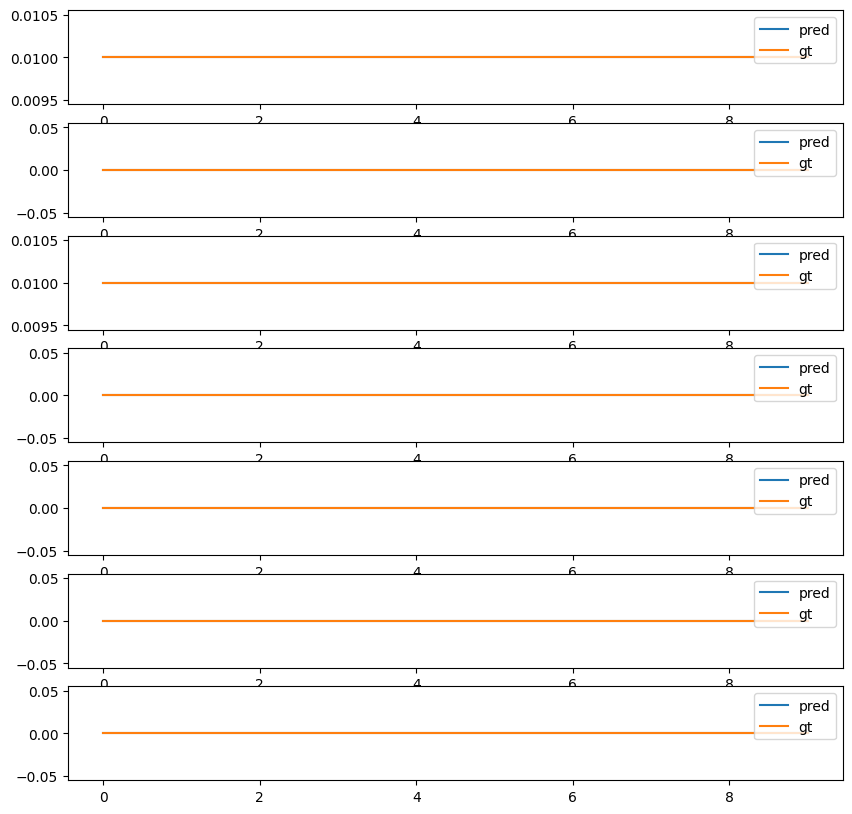

In [13]:
'''
plot actions and gt_actions
'''
import matplotlib.pyplot as plt
action_dim = 7

fig, axs = plt.subplots(action_dim, 1, figsize=(10, 10))

for i in range(action_dim):
    axs[i].plot(actions[:, i].cpu().detach().numpy(), label="pred")
    axs[i].plot(gt_actions[:, i].cpu().detach().numpy(), label="gt")
    axs[i].legend()
plt.show()